# Robot Predictive Maintenance — Data Streaming and Visualization

**Group 4 — Namy, Davis, Carlos, Rangeetha**

A materials-handling robot failed and took 480 minutes of production with it. The failure was wear in a torque tube, and nobody saw it coming because there was no way to watch the robot's health while it ran.

This notebook builds the tool that would have seen it. It reads the electrical current each of the robot's joints draws, stores every reading in a cloud database, shows them on a live chart, and looks for readings that suggest something is going wrong.

**The data.** One Kawasaki robot, recorded on 17–18 October 2022. 39,672 readings taken about every 2 seconds across 22.5 hours. Each reading is the current in amps for eight joints. The export format has fourteen axis columns but this robot only has eight, so columns 9 to 14 are empty in every row.

**How it fits together.**

```
CSV file  ->  StreamingSimulator  ->  insert_reading()  ->  Neon database
                                   -> dashboard.update()  ->  live chart
                                                    Neon  ->  fetch_all()  ->  analysis
```

**Who built what.** Rangeetha set up the Neon database and the functions that read and write it. Davis wrote the simulator that replays the CSV as if a robot controller were sending it. Carlos built the dashboard and the standalone web app. Namy wrote the analysis and anomaly detection, and merged everyone's work together.

The instructor's brief is in `instructor_material.ipynb`.

## Setup

Run this section first — every later cell depends on it.

**What this cell does:** loads the tools we need and sets up where things live.

- `pandas` handles tables of data. A table in pandas is called a **DataFrame** — think of a spreadsheet you can work with in code.
- `matplotlib` draws charts.
- `clear_output` and `display` let us replace a chart in place, which is how the live dashboard appears to animate.

`CSV_PATH` is where the raw data file sits. `AXIS_COLUMNS` is the list of the eight joints we care about, so we never have to type them out again.

`CANONICAL_MAX_ID` marks where the real data ends. Our one-time data load filled rows 1 to 39,672, so any row numbered higher than that was added later by a demo and can be safely deleted.

In [68]:
# CELL 1: imports, paths, constants
import sys
from pathlib import Path

from matplotlib import pyplot as plt
import pandas as pd
from IPython.display import clear_output, display
# from src.web_ui import web_ui_interface


REPO_ROOT = Path.cwd()
CSV_PATH = REPO_ROOT / 'data'/ "RMBR4-2_export_test.csv"
AXIS_COLUMNS = [f"axis_{i}" for i in range(1, 9)]

# ids 1..39,672 came from the one-time bulk migration. Anything above this
# was added by a live demo and is removed after Step 2, so repeated demo runs
# never accumulate in the table.
CANONICAL_MAX_ID = 39_672


## Step 1 — Connect to the database and load the data

Before we can stream anything we need two things: somewhere to put the readings, and the readings themselves.

**What this cell does:** connects to our Neon database and pulls every stored reading into a DataFrame.

Neon is a PostgreSQL database that runs in the cloud, so all four of us read and write the same table from our own laptops.

The four functions come from `src/data_collection/data_collection_agent.py`:

| function | what it does |
|---|---|
| `get_connection()` | opens a connection to the database |
| `insert_reading()` | saves one reading |
| `fetch_all()` | reads every reading back as a DataFrame |
| `fetch_since()` | reads only readings newer than a given time |

We should see **39,672 rows**. Each row has an `id` (a row number the database assigns), the eight currents in amps, and `reading_time` — when the controller took that measurement.

In [69]:
# CELL 2: connect to Neon and confirm the table
from src.data_collection.data_collection_agent import fetch_all, fetch_since, get_connection, insert_reading
readings = fetch_all()
print(f"{len(readings):,} rows in robot_readings")
readings.head(20)


39,672 rows in robot_readings


    id    trait  axis_1  axis_2  axis_3  axis_4  axis_5  axis_6  axis_7  \
0    1  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1    2  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2    3  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3    4  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4    5  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5    6  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
6    7  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
7    8  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
8    9  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
9   10  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
10  11  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
11  12  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
12  13  current     0.0  

**What this cell does:** reads the same data straight from the CSV file, so we have a copy in memory as well as in the database.

Two things happen. `usecols` keeps only the eight axes that hold data, ignoring the six empty ones. Then we rename the columns so the CSV's names match the database's names — `Axis #1` becomes `axis_1`, `Time` becomes `reading_time`.

That rename is small but it saves real trouble. Because both sources now use identical names, any analysis we write works on either one without changing a single line.

In [70]:
# CELL 3: load the CSV into a DataFrame
df_raw = pd.read_csv(
    CSV_PATH,
    usecols=["Trait", *[f"Axis #{i}" for i in range(1, 9)], "Time"],
    parse_dates=["Time"]
)
df_raw = df_raw.rename(
    columns={
         "Trait": "trait",
        "Time": "reading_time",
        **{f"Axis #{i}": f"axis_{i}" for i in range(1, 9)},
    }
)
print(f"{len(df_raw):,} rows loaded from CSV")
df_raw.head()

39,672 rows loaded from CSV


     trait  axis_1  axis_2  axis_3  axis_4  axis_5  axis_6  axis_7  axis_8  \
0  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

                      reading_time  
0 2022-10-17 12:18:23.660000+00:00  
1 2022-10-17 12:18:25.472000+00:00  
2 2022-10-17 12:18:27.348000+00:00  
3 2022-10-17 12:18:29.222000+00:00  
4 2022-10-17 12:18:31.117000+00:00  

### Team Talking Point — Step 1

**The table we first created was shaped by the file, not by the data.**

Our first load handed the CSV straight to pandas' `to_sql()`, which builds a table by copying
whatever the file looks like. That gave us all fourteen axis columns — including the six that are
empty in every one of the 39,672 rows — and it stored the timestamp as plain text rather than as a
date.

The text timestamp was the real problem. A database can group text alphabetically but it cannot
group it by hour, so the hourly analysis in Step 3 was impossible until we fixed it.

We rebuilt the table with eight axis columns and a proper timestamp type. Because all four of us
share one database, we did not drop the old table and start again — anyone running a query during
the reload would have hit a table that did not exist. Instead we built the new table alongside the
old one, loaded it, checked the row count and time span matched exactly, and only then renamed the
two tables. That swap takes milliseconds. The old table is still there as `robot_readings_old`.

## Step 2 — Stream the readings live

The robot controller sends one reading every couple of seconds. We replay the CSV at that same pace so the rest of the system behaves exactly as it would against a real robot.

**What this cell does:** creates the simulator that stands in for the robot controller.

`nextDataPoint()` hands back one reading at a time and remembers where it got to, the way a controller would send one message after another.

Look at the keys it returns: `trait`, `axis_1` … `axis_8`, `reading_time`. Those are exactly the column names in our database, which means a reading can be saved with no conversion step in between. Getting the two sides to agree on names was the main thing we had to fix when we merged our work.

In [71]:
# CELL 4: StreamingSimulator: one reading via nextDataPoint()
from src.data_collection.streaming_simulator import StreamingSimulator

ss = StreamingSimulator(CSV_PATH) 
first_record = ss.nextDataPoint()
first_record


{'trait': 'current',
 'axis_1': np.float64(0.0),
 'axis_2': np.float64(0.0),
 'axis_3': np.float64(0.0),
 'axis_4': np.float64(0.0),
 'axis_5': np.float64(0.0),
 'axis_6': np.float64(0.0),
 'axis_7': np.float64(0.0),
 'axis_8': np.float64(0.0),
 'reading_time': Timestamp('2022-10-17 12:18:23.660000+0000', tz='UTC')}

**What this cell does:** builds the live dashboard.

It keeps the most recent 30 readings and redraws the chart each time a new one arrives. Older readings drop off the end, so the chart always shows roughly the last minute — which is what a live dashboard is for. The full history stays in the database.

The chart is a **stacked area chart**: each joint's current is piled on top of the one below, so the height of the whole stack is the robot's total draw and each coloured band is one joint's share. This matches the dashboard design in the use case.

Each joint keeps the same colour throughout, so Axis 3 is always the same green. We checked the eight colours stay distinguishable for colourblind readers, and we print the exact amps under the chart as well — colour should never be the only way to read a chart.

Running this cell only sets the dashboard up. Nothing is drawn until readings arrive.

In [72]:
# Validated 8-hue categorical palette, assigned to axes in fixed order.
# Never cycle or reorder these -- axis_3 must stay the same color when the
# chart is filtered or rescaled, or the reader has to re-learn it every tick.
AXIS_COLORS = {
    "axis_1": "#2a78d6",  # blue
    "axis_2": "#eb6834",  # orange
    "axis_3": "#1baf7a",  # aqua
    "axis_4": "#eda100",  # yellow
    "axis_5": "#e87ba4",  # magenta
    "axis_6": "#008300",  # green
    "axis_7": "#4a3aa7",  # violet
    "axis_8": "#e34948",  # red
}

SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_MUTED = "#52514e"


class LiveDashboard:
    """Rolling per-axis current chart that redraws as readings arrive."""

    def __init__(self, window=30):
        self.window = window
        self.records = []

    def update(self, record):
        self.records.append(record)
        self.records = self.records[-self.window:]
        self.draw()

    def draw(self):
        df = pd.DataFrame(self.records)

        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(11, 4.5), facecolor=SURFACE)
        ax.set_facecolor(SURFACE)

        for column in AXIS_COLUMNS:
            ax.plot(
                df["reading_time"], df[column],
                color=AXIS_COLORS[column], linewidth=2,
                solid_capstyle="round", label=column.replace("axis_", "Axis "),
            )

        ax.set_title(
            f"Robot current by axis — last {len(df)} readings",
            color=INK, fontsize=13, fontweight="600", loc="left", pad=12,
        )
        ax.set_ylabel("current (A)", color=INK_MUTED, fontsize=10)
        ax.tick_params(colors=INK_MUTED, labelsize=9)

        # Recessive grid and axes: the data should be the darkest thing here.
        ax.grid(axis="y", color="#d8d7d2", linewidth=0.8, alpha=0.7)
        ax.set_axisbelow(True)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color("#d8d7d2")

        # Legend outside the plot so it never covers the data.
        ax.legend(
            loc="center left", bbox_to_anchor=(1.01, 0.5),
            frameon=False, fontsize=9, labelcolor=INK_MUTED,
        )

        fig.autofmt_xdate()
        fig.tight_layout()
        display(fig)
        plt.close(fig)

        # Relief for the low-contrast hues: current values in text, not color alone.
        latest = df.iloc[-1]
        print("  ".join(f"{c.replace('axis_', 'A')}:{latest[c]:5.1f}" for c in AXIS_COLUMNS))


dashboard = LiveDashboard(window=30)
print("dashboard ready")


dashboard ready


**What this cell does:** the streaming demo itself.

For each reading we save it to the database and redraw the chart, one reading every 2 seconds as the brief asks. Thirty readings takes about a minute.

`on_tick` is a **callback** — a function we hand to the simulator so it can call us back once per reading. It keeps the simulator ignorant of databases and charts; it just announces each reading and we decide what to do with it.

**Why we start at reading 11,604.** The recording opens at 12:18 while the robot is sitting still, so streaming from the beginning drew a flat line at zero. Reading 11,604 starts a stretch where the robot is working and where nothing is missing from the recording. Step 3 still analyses all 39,672 readings, idle ones included.

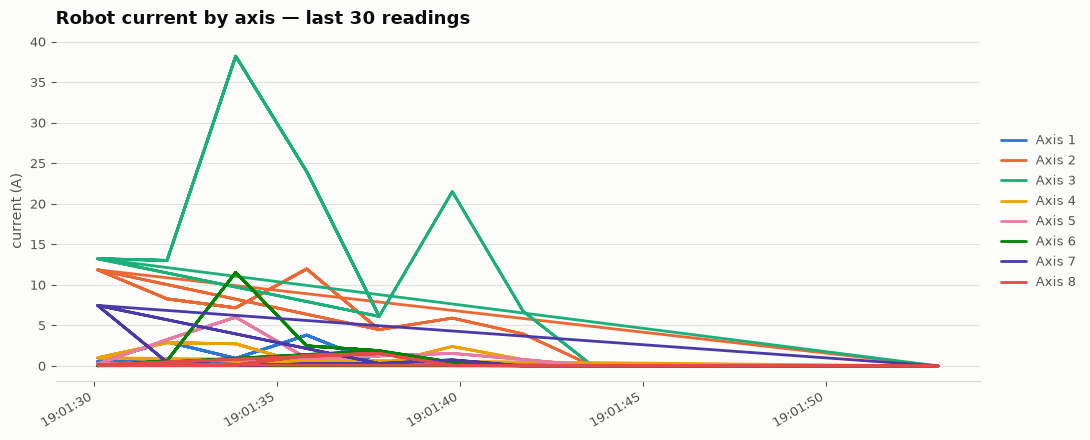

A1:  0.0  A2:  0.0  A3:  0.0  A4:  0.0  A5:  0.0  A6:  0.0  A7:  0.0  A8:  0.0


In [ ]:
# CELL 6: stream a slice: insert into Neon + update the chart each tick


def on_tick(record):
    """One tick: persist the reading, then redraw the chart"""
    insert_reading(record)
    dashboard.update(record)


ss = StreamingSimulator(CSV_PATH)   # interval=2.0 default, per the instruction

# The file opens during an idle stretch, so stream from a window where the robot
# is working and the recording has no gaps. Step 3 analyses the full dataset.
ss.seek(11604)

demo_records = ss.run(n_steps=30, on_tick=on_tick)
print(f"streamed {len(demo_records)} readings at {ss.interval}s intervals")



**What this cell does:** deletes the rows the demo just added, putting the table back to its 39,672 real readings.

The demo writes into the same table we analyse, so without this every run would leave duplicates behind and slowly distort our results.

We delete everything numbered above `CANONICAL_MAX_ID`. Our first attempt compared against whatever the highest row number was just before the demo started, which quietly broke when we ran the demo twice without cleaning up in between — the second run's baseline already included the first run's leftovers. 270 stray rows built up and shifted our anomaly counts before we caught it. Pinning a fixed number fixes it no matter how often the demo runs.

In [74]:
with get_connection() as connection:
    deleted = connection.execute(
        "DELETE FROM robot_readings WHERE id > %s", (CANONICAL_MAX_ID,)
    ).rowcount
    connection.commit()

print(f"removed {deleted} demo rows; table back to its canonical {len(fetch_all()):,}")


removed 30 demo rows; table back to its canonical 39,672


### Team Talking Point — Step 2

**Our first live demo drew a flat line at zero, and the chart was right.**

Rather than assume the dashboard was broken, we checked it against our own data profile and found
the robot genuinely is not moving for the first 30 readings — 64% of the whole dataset is idle. The
recording simply opens during a quiet period.

Our second attempt found a subtler problem. The window we picked straddled a 33-second gap in the
recording, and a stacked area chart joins the points either side of a gap with a straight line. The
chart showed a smooth ramp during a period when there was no data at all. On a real maintenance
dashboard that is worse than a blank space, because it invents a trend an operator might act on. We
moved to a window with no gaps and said so in the code comment.

Both problems looked like chart bugs and neither was. Knowing what the data actually contains is
what let us tell the difference.

## Step 3 — Find patterns in the data

Before deciding what counts as abnormal, we need to know what normal looks like.

**What this cell does:** our first proper look at the data.

A reading counts as **idle** when all eight joints read exactly zero — the controller is still reporting, but the robot isn't moving. That distinction turns out to matter a lot later.

We print three things:

1. How much of the time the robot is idle versus working
2. The average current on each joint while it is working
3. The percentage of each hour spent idle

For the per-joint averages we deliberately leave the idle readings out. Including all those zeros would drag every average toward zero and tell us nothing about how hard each joint actually works when it runs.

In [75]:
# CELL 7: data profile: idle vs active, per-axis load, hourly idle %
df = fetch_all()

# A reading is "idle" only when every axis reads exactly zero.
df["idle"] = (df[AXIS_COLUMNS] == 0).all(axis=1)

print(f"total readings : {len(df):,}")
print(f"idle           : {df['idle'].sum():,}  ({df['idle'].mean():.1%})")
print(f"active         : {(~df['idle']).sum():,}  ({(~df['idle']).mean():.1%})")

print("\nmean current per axis when active:")
print(df.loc[~df["idle"], AXIS_COLUMNS].mean().round(2).to_string())

print("\nidle % per hour:")
df["hour"] = df["reading_time"].dt.floor("h")
hourly = df.groupby("hour").agg(readings=("idle", "size"), idle_pct=("idle", "mean"))
hourly["idle_pct"] = (hourly["idle_pct"] * 100).round(1)
print(hourly.to_string())


total readings : 39,672
idle           : 25,487  (64.2%)
active         : 14,185  (35.8%)

mean current per axis when active:
axis_1     2.03
axis_2    10.11
axis_3     7.58
axis_4     1.73
axis_5     2.67
axis_6     1.68
axis_7     2.43
axis_8     0.29

idle % per hour:
                           readings  idle_pct
hour                                         
2022-10-17 12:00:00+00:00      1040      73.3
2022-10-17 13:00:00+00:00      1623      61.4
2022-10-17 14:00:00+00:00      1784      44.4
2022-10-17 15:00:00+00:00      1756      72.1
2022-10-17 16:00:00+00:00      1798      99.8
2022-10-17 17:00:00+00:00      1778      82.1
2022-10-17 18:00:00+00:00      1782      51.4
2022-10-17 19:00:00+00:00      1782      49.7
2022-10-17 20:00:00+00:00      1765      43.3
2022-10-17 21:00:00+00:00      1788      59.2
2022-10-17 22:00:00+00:00      1785      58.3
2022-10-17 23:00:00+00:00      1782      45.7
2022-10-18 00:00:00+00:00      1791      60.1
2022-10-18 01:00:00+00:00      1782   

#### Step 3 findings

**The robot is idle about two-thirds of the time.** 25,487 of 39,672 readings have all eight joints
at exactly zero — 64.2% idle, 35.8% active. The controller keeps reporting every ~2 seconds
regardless, so idle readings are real measurements of a stationary robot, not missing data.

**Two joints do most of the work.** While active, axis 2 averages 10.1A and axis 3 averages 7.6A.
The other six sit between 0.3A and 2.7A. Across the whole dataset those two account for 62% of all
current drawn, and axis 8 for 1%.

**There is a three-hour production stoppage.** Four hours stand out sharply from the usual 43–82%
idle:

| Hour (UTC) | Idle % |
|---|---|
| Oct 17 16:00 | 99.8% |
| Oct 18 03:00 | 95.4% |
| Oct 18 04:00 | 100.0% |
| Oct 18 05:00 | 99.6% |

The three consecutive hours on 18 October form one continuous stop. Crucially the controller kept
reporting about 1,780 readings per hour throughout, so this is a robot that was powered and being
monitored but not moving — a production stoppage, not a monitoring failure. Those look identical on
a chart of total current and mean completely different things to a maintenance team.

**The recording has two real gaps**, of 402 seconds and 333 seconds, both on 17 October.

### Team Talking Point — Step 3

**Because most readings are zero, the obvious way to average the data gives the wrong answer.**

Taking a plain average of axis 2 across every reading gives 3.6A. Averaging only the readings where
the robot is actually moving gives 10.1A. The first number is not a property of the joint at all —
it is mostly a measure of how often the robot was switched on, and it would drift every time
production schedules changed.

Every figure we report in this notebook is calculated over active readings only, and the same idea
decides what counts as an anomaly in Step 4. It is the single assumption that shaped the whole
analysis, so we made it explicit rather than leaving it buried in the code.

## Step 4 — Turn the patterns into maintenance alerts

A dashboard that only draws lines still needs a person watching it. This step looks for the readings worth raising an alert about.

**What this cell does:** looks for unusual readings, and for any sign the robot is wearing out.

These are two different questions and they need two different methods.

**Sudden spikes.** We use a **rolling z-score**. A z-score says how far a reading sits from the recent average, measured in standard deviations — a rough unit of 'how spread out the recent readings have been'. A z-score above 3 means a reading is further from normal than almost anything else that joint has done lately. 'Rolling' means we only compare against the last 30 readings rather than the whole day, so the baseline moves with the robot's workload.

**Gradual wear.** We also track whether a joint slowly draws more current over time for the same work. Rising current means rising friction, and that is what eventually becomes a failure like the torque tube in our use case. This is the genuinely predictive half.

**One important detail.** We only compare active readings against other active readings. Since 64% of the data is idle zeros, a window full of zeros has almost no spread, and the moment the robot moves the z-score explodes. Left unfiltered it flagged 780 anomalies on axis 2 instead of 242 — every one of them just the robot starting to move.

2,457 anomalies flagged across all 8 axes

per axis:
axis
axis_1    380
axis_2    242
axis_3    279
axis_4    379
axis_5    250
axis_6    393
axis_7      1
axis_8    533

most severe by amps above recent baseline:
                    reading_time   axis  value  deviation_amps  z_score
2022-10-18 09:54:06.999000+00:00 axis_2  51.24           39.60     3.78
2022-10-17 19:08:22.349000+00:00 axis_2  51.66           39.23     3.37
2022-10-18 00:17:44.012000+00:00 axis_2  49.50           39.21     4.06
2022-10-18 09:04:00.191000+00:00 axis_2  51.71           39.05     3.52
2022-10-17 19:36:05.504000+00:00 axis_2  50.45           38.79     3.56

per axis, ranked by total excess current:
        count     sum   max
axis                       
axis_2    242  7218.6  39.6
axis_3    279  5793.5  34.0
axis_1    380  4700.7  20.4
axis_6    393  4128.7  18.8
axis_4    379  3322.4  13.9
axis_5    250  2783.3  17.8
axis_8    533  1534.3   5.4
axis_7      1     6.6   6.6

most extreme readings:
       

/var/folders/g2/g_7dn1xs0wj014452rh7wmf80000gn/T/ipykernel_50765/2032984823.py:34: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2).to_string(index=False))


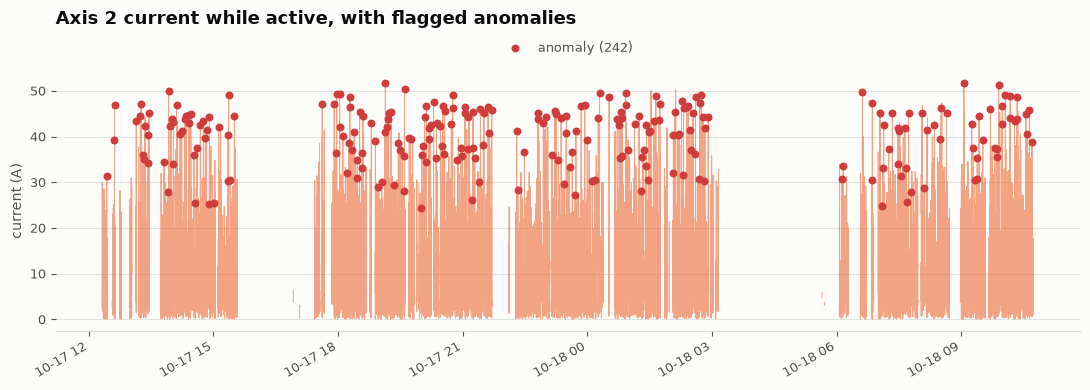

In [76]:
# CELL 8: anomaly detection on active samples + degradation trend
CRITICAL = "#d03b3b"   # reserved status colour -- never used for a series


def detect_anomalies(df, axis_col, window=30, threshold=3.0):
    """Flag readings far outside what this axis has been doing recently.

    Only active readings are compared with other active readings. 64% of the
    data is idle zeros, so including them would make every start of movement
    look like an anomaly.
    """
    active = df[df[axis_col] > 0].copy()
    rolling_mean = active[axis_col].rolling(window).mean()
    rolling_std = active[axis_col].rolling(window).std()

    active["z_score"] = (active[axis_col] - rolling_mean) / rolling_std
    active["deviation_amps"] = active[axis_col] - rolling_mean
    flagged = active[active["z_score"].abs() > threshold].copy()
    flagged["axis"] = axis_col
    flagged["value"] = flagged[axis_col]
    return flagged[["reading_time", "axis", "value", "z_score","deviation_amps"]]


alerts = pd.concat(
    [detect_anomalies(df, column) for column in AXIS_COLUMNS], ignore_index=True
).sort_values("reading_time", ignore_index=True)

print(f"{len(alerts):,} anomalies flagged across all 8 axes\n")
print("per axis:")
print(alerts.groupby("axis").size().to_string())

print("\nmost severe by amps above recent baseline:")
print(alerts.nlargest(5, "deviation_amps")[["reading_time", "axis", "value", "deviation_amps", "z_score"]]
      .round(2).to_string(index=False))

print("\nper axis, ranked by total excess current:")
print(alerts.groupby("axis")["deviation_amps"].agg(["count", "sum", "max"])
      .round(1).sort_values("sum", ascending=False).to_string())

print("\nmost extreme readings:")
worst = alerts.loc[alerts["z_score"].abs().nlargest(5).index]
print(worst.to_string(index=False))
# Degradation check: is any axis drawing more current over time for the same work?
active_only = df[~df["idle"]]
hourly_mean = active_only.groupby("hour")[AXIS_COLUMNS].mean()
hourly_mean["total"] = hourly_mean.sum(axis=1)

first, last = hourly_mean["total"].iloc[0], hourly_mean["total"].iloc[-1]
print(f"\ntotal active current, first hour: {first:.1f}A")
print(f"total active current, last hour : {last:.1f}A")
print(f"change over {len(hourly_mean)} hours: {(last - first) / first:+.1%}")

fig, ax = plt.subplots(figsize=(11, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

axis_2_active = df[df["axis_2"] > 0].copy()

# Break the line wherever the robot stopped for more than a minute. Without this
# matplotlib joins the points either side of a three-hour stoppage with a straight
# line, which draws a trend across a period that has no readings at all.
stopped = axis_2_active["reading_time"].diff().dt.total_seconds() > 60
axis_2_active.loc[stopped, "axis_2"] = float("nan")

ax.plot(axis_2_active["reading_time"], axis_2_active["axis_2"],
        color=AXIS_COLORS["axis_2"], linewidth=0.7, alpha=0.6)

axis_2_alerts = alerts[alerts["axis"] == "axis_2"]
ax.scatter(axis_2_alerts["reading_time"], axis_2_alerts["value"],
           color=CRITICAL, s=22, zorder=3, label=f"anomaly ({len(axis_2_alerts)})")

ax.set_title("Axis 2 current while active, with flagged anomalies",
             color=INK, fontsize=13, fontweight="600", loc="left", pad=34)
ax.set_ylabel("current (A)", color=INK_MUTED, fontsize=10)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color="#d8d7d2", linewidth=0.8, alpha=0.7)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
ax.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED,
          loc="lower center", bbox_to_anchor=(0.5, 1.02))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


### Our detector flags 2,457 anomalies, but the count is misleading in two ways. First, a z-score measures deviation relative to each axis's own behaviour, so axis 8 — which normally draws 0.3A — produces 533 flags for excursions of 3–4A, while axis 2's genuinely heavy 51A spikes produce only 242. Second, the rolling z-score has a hard mathematical ceiling of (n−1)/√n, which for our 30-reading window is 5.2947; five of our flags sit at that ceiling, where a mild excursion and a catastrophic one score identically. Ranking by current above the recent baseline inverts the picture: axis 2 accounts for 7,219A of excess against axis 8's 1,534A. Maintenance attention belongs on axes 2 and 3. We report the z-score for detection and amps above baseline for severity.

### Team Talking Point — Step 4

**Our anomaly detector is statistically correct and would send an engineer to the wrong joint.**

Two separate problems, both visible in our own output.

First, a z-score asks whether a reading is unusual *for that joint*. Axis 8 normally draws 0.3A, so
a 4A excursion looks enormous and it produced 533 flags — more than any other joint. Axis 2's
genuinely heavy 51A spikes produced 242. Ranked by count, the joint that matters least comes first.

Second, the rolling z-score has a hard mathematical ceiling. A single reading inside a window of
`n` can never score further than `(n-1)/√n` from the mean, because it is part of the mean it is
being compared to. For our 30-reading window that limit is 5.2947, and five of our flags sit at it.
We confirmed this by testing a window of 29 identical values against an outlier of 10 and an
outlier of 1,000,000 — both scored exactly 5.294651. Past the ceiling, a mild excursion and a
catastrophic one are indistinguishable.

Ranking by current above the recent baseline instead inverts the picture entirely: axis 2 accounts
for 7,219A of excess current against axis 8's 1,534A. So we report the z-score for **detection**
and amps above baseline for **severity**, and the maintenance attention belongs on axes 2 and 3.

**On the prediction itself, our honest answer is that there is nothing to predict here yet.** Total
active current is 28.5A in the first hour and 28.3A in the last — a 0.6% drift over 22.5 hours,
which is noise. No joint is degrading. That is the expected result: torque tube wear develops over
weeks or months, and 22.5 hours cannot show it. What this notebook delivers is the instrument that
would catch it once the data keeps arriving, plus a concrete trigger for when it should raise an
alarm — an hourly active mean for a joint rising more than 15% above its established baseline.

## Extra — A summary chart for the whole dataset

**What this cell does:** one chart covering all 39,672 readings instead of a live window,
showing how much current each joint uses overall.

We add up every reading for a joint and multiply by the time between readings, which gives
**amp-seconds** — current accumulated over time. It is not watts, because the controller does not
report voltage, so treat it as a way of comparing the joints against each other rather than a real
power figure.

A horizontal bar chart suits this because we are comparing eight named things by size, and
horizontal bars leave room for the labels. Each bar carries its own value and percentage, so
nothing depends on matching a colour to a legend. The bars keep the same colours the joints have
everywhere else in the notebook.

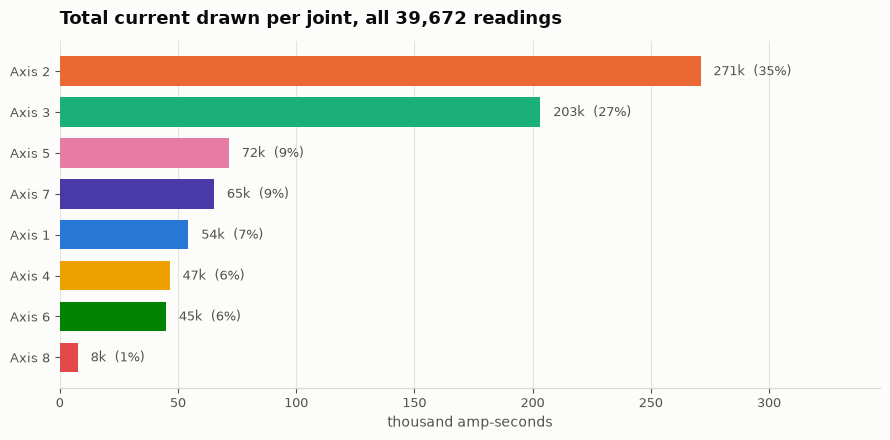

Axes 2 and 3 together account for 62% of all current drawn.
Axis 8 accounts for 1.0%.


In [77]:
# CELL 9: summary chart: energy consumption per axis, whole dataset
summary = fetch_all()
SAMPLE_SECONDS = summary["reading_time"].diff().dt.total_seconds().median()

# Energy proxy: current added up over time, in amp-seconds. We have no voltage
# reading, so this is not watts -- it compares the joints against each other.
energy = (summary[AXIS_COLUMNS].sum() * SAMPLE_SECONDS).sort_values()
share = energy / energy.sum()

fig, ax = plt.subplots(figsize=(9, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

bars = ax.barh(
    [name.replace("axis_", "Axis ") for name in energy.index],
    energy.values / 1000,
    color=[AXIS_COLORS[name] for name in energy.index],
    height=0.72,
)

# Label every bar directly, so the numbers never depend on reading a colour.
for bar, value, pct in zip(bars, energy.values, share.values):
    ax.text(
        bar.get_width() + energy.max() / 1000 * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value / 1000:,.0f}k  ({pct:.0%})",
        va="center", fontsize=9, color=INK_MUTED,
    )

ax.set_title(
    f"Total current drawn per joint, all {len(summary):,} readings",
    color=INK, fontsize=13, fontweight="600", loc="left", pad=12,
)
ax.set_xlabel("thousand amp-seconds", color=INK_MUTED, fontsize=10)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.set_xlim(0, energy.max() / 1000 * 1.28)
ax.grid(axis="x", color="#d8d7d2", linewidth=0.8, alpha=0.7)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
fig.tight_layout()
plt.show()

heavy = share[["axis_2", "axis_3"]].sum()
print(f"Axes 2 and 3 together account for {heavy:.0%} of all current drawn.")
print(f"Axis 8 accounts for {share['axis_8']:.1%}.")


## 🖥️ Appendix: standalone Dash dashboard

The notebook charts above are self-contained. `src/web_ui/` also holds a standalone Dash app built on the same database interface; run it with `python src/web_ui/web_ui_interface.py`.